<h4>Klasyfikacja par zdań (tzw. przesłanki i hipotezy) do jednej z trzech kategorii używając w tym celu sieci rekurencyjnej biLSTM</h4>
<h5>Dane wykorzystane do tego projektu znajdują się pod linkiem:</h5>

 https://nlp.stanford.edu/projects/snli/

In [2]:
!unzip snli_1.0.zip

Archive:  snli_1.0.zip
replace snli_1.0/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [3]:
import pandas as pd

data_train = pd.read_json("/content/snli_1.0/snli_1.0_train.jsonl", lines = True)
print(data_train.head())

  annotator_labels         captionID     gold_label               pairID  \
0        [neutral]  3416050480.jpg#4        neutral  3416050480.jpg#4r1n   
1  [contradiction]  3416050480.jpg#4  contradiction  3416050480.jpg#4r1c   
2     [entailment]  3416050480.jpg#4     entailment  3416050480.jpg#4r1e   
3        [neutral]  2267923837.jpg#2        neutral  2267923837.jpg#2r1n   
4     [entailment]  2267923837.jpg#2     entailment  2267923837.jpg#2r1e   

                                           sentence1  \
0  A person on a horse jumps over a broken down a...   
1  A person on a horse jumps over a broken down a...   
2  A person on a horse jumps over a broken down a...   
3              Children smiling and waving at camera   
4              Children smiling and waving at camera   

                              sentence1_binary_parse  \
0  ( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...   
1  ( ( ( A person ) ( on ( a horse ) ) ) ( ( jump...   
2  ( ( ( A person ) ( on ( a horse ) )

In [4]:
data_train.shape

(550152, 10)

In [5]:
data_train["sentence1"][0]

'A person on a horse jumps over a broken down airplane.'

In [6]:
data_train["sentence2"][0]

'A person is training his horse for a competition.'

In [7]:
data_train["gold_label"][0]

'neutral'

In [8]:
data_test = pd.read_json("/content/snli_1.0/snli_1.0_test.jsonl", lines = True)

In [9]:
data_val = pd.read_json("/content/snli_1.0/snli_1.0_dev.jsonl", lines = True)

<h5>Sprawdzenie liczoności poszczególnych klas

In [10]:
print(data_train["gold_label"].value_counts())

gold_label
entailment       183416
contradiction    183187
neutral          182764
-                   785
Name: count, dtype: int64


In [11]:
print(data_test["gold_label"].value_counts())

gold_label
entailment       3368
contradiction    3237
neutral          3219
-                 176
Name: count, dtype: int64


In [12]:
print(data_val["gold_label"].value_counts())

gold_label
entailment       3329
contradiction    3278
neutral          3235
-                 158
Name: count, dtype: int64


<h5>Usunięcie z zbiorów elementów o gold_label = "-"

In [13]:
data_train = data_train[data_train["gold_label"] != "-"].reset_index(drop=True)
data_test = data_test[data_test["gold_label"]!= "-"].reset_index(drop=True)
data_val = data_val[data_val["gold_label"]!= "-"].reset_index(drop=True)

In [14]:
print(data_train["gold_label"].value_counts())

gold_label
entailment       183416
contradiction    183187
neutral          182764
Name: count, dtype: int64


In [15]:
import torch
import torch.nn as nn
import torchtext
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from torchtext.vocab import GloVe
from torchtext.data.utils import get_tokenizer
from torch.utils.data import Dataset, DataLoader

/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated

In [16]:
tokenizer = get_tokenizer("basic_english")
glove = torchtext.vocab.GloVe(name="6B", dim=50)

.vector_cache/glove.6B.zip: 862MB [05:55, 2.42MB/s]                           
100%|█████████▉| 399999/400000 [00:11<00:00, 33790.71it/s]


In [17]:
label_map = {"entailment": 0, "contradiction": 1, "neutral":2}

In [19]:
#Przygotowywanie danych
def data_prep(df):
    premise_sent = df["sentence1"].tolist()
    hypoth_sent = df["sentence2"].tolist()
    numeric_labels = df["gold_label"].map(label_map).tolist()
    return premise_sent, hypoth_sent, numeric_labels

X_train_pr, X_train_hy, y_train = data_prep(data_train)
X_val_pr, X_val_hy, y_val = data_prep(data_val)
X_test_pr, X_test_hy, y_test = data_prep(data_test)

In [20]:
print(X_train_pr[0])

A person on a horse jumps over a broken down airplane.


In [21]:
#Zamiana tekstów na indeksy
def text_to_indices(text):
    return [glove.stoi.get(token, 0) for token in tokenizer(text)]

In [22]:
#Tworzenie klasy dla danych
class TextDataset(Dataset):
    def __init__(self, premises, hypothesis, labels):
        self.premises = [torch.tensor(text_to_indices(p), dtype=torch.long) for p in premises]
        self.hypothesis = [torch.tensor(text_to_indices(h), dtype=torch.long) for h in hypothesis]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.premises[idx], self.hypothesis[idx], self.labels[idx]

dataset_train = TextDataset(X_train_pr, X_train_hy, y_train)
dataset_val = TextDataset(X_val_pr, X_val_hy, y_val)
dataset_test = TextDataset(X_test_pr, X_test_hy, y_test)

In [23]:
#collate_fn do obsługi paddingu i długości
def collate_batch(batch):
    premises, hypotheses, labels = zip(*batch)

    pr_lens = torch.tensor([len(p) for p in premises])
    hy_lens = torch.tensor([len(h) for h in hypotheses])

    pr_padded = pad_sequence(premises, batch_first=True)
    hy_padded = pad_sequence(hypotheses, batch_first=True)

    return (pr_padded, pr_lens), (hy_padded, hy_lens), torch.tensor(labels)

In [24]:
#DataLoader z collate_fn i do obsługi batcha
loader_train = DataLoader(dataset_train, batch_size=1000, shuffle=True, collate_fn=collate_batch)
loader_val = DataLoader(dataset_val, batch_size=1000, shuffle=False, collate_fn=collate_batch)
loader_test = DataLoader(dataset_test, batch_size=1000, shuffle=False, collate_fn=collate_batch)

In [36]:
#model biLSTM liniowy
class biLSTM_Classifier(nn.Module):
    def __init__(self, embedding_dim, hidden_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(glove.vectors, freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size*2*2, num_classes)

    def forward(self, premise_pack, hypothesis_pack):
        pr_data, pr_lens = premise_pack
        hy_data, hy_lens = hypothesis_pack

        #przetwarzanie przesłanki
        embedded_pr = self.embedding(pr_data)
        packed_pr = pack_padded_sequence(embedded_pr, pr_lens.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn_pr, _) = self.lstm(packed_pr)
        pr_vec = torch.cat((hn_pr[-2,:,:], hn_pr[-1,:,:]), dim=1)

        #przetwarzanie hipotezy
        embedded_hy = self.embedding(hy_data)
        packed_hy = pack_padded_sequence(embedded_hy, hy_lens.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn_hy, _) = self.lstm(packed_hy)
        hy_vec = torch.cat((hn_hy[-2,:,:], hn_hy[-1,:,:]), dim=1)

        combined = torch.cat((pr_vec, hy_vec), dim=1)#Konkatenacja wektorów

        return self.fc(combined)

In [37]:
import matplotlib.pyplot as plt
def get_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for pr_pack, hy_pack, labels in loader:
            pr_idx, pr_len = pr_pack
            hy_idx, hy_len = hy_pack

            pr_pack = (pr_idx.to(device), pr_len)
            hy_pack = (hy_idx.to(device), hy_len)
            labels = labels.to(device)

            outputs = model(pr_pack, hy_pack)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


def train(model, train_dataset, val_dataset,device, batch_size=1000, num_epochs=2, learn_rate=0.01):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learn_rate)

    losses, train_acc, val_acc = [], [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        for pr_pack, hy_pack, labels in train_loader:
            pr_idx, pr_len = pr_pack
            hy_idx, hy_len = hy_pack
            pr_pack = (pr_idx.to(device), pr_len)
            hy_pack = (hy_idx.to(device), hy_len)
            labels = labels.to(device)
            #Forward
            out = model(pr_pack, hy_pack)
            loss = criterion(out, labels)

            #Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            #liczenie accuracy na bieżąco
            preds = out.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        # średni loss z epoki
        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)

        # accuracy raz na epokę
        train_accuracy = train_correct / train_total
        val_accuracy = get_accuracy(model, val_loader, device)

        train_acc.append(train_accuracy)
        val_acc.append(val_accuracy)

        if epoch%1 == 0: #drukowanie przy każdej epoce
            print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, "
                  f"Train Acc: {train_accuracy:.4f}, Val Acc: {val_accuracy:.4f}")

    # wykresy
    plt.plot(losses)
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.plot(train_acc, label="Train")
    plt.plot(val_acc, label="Validation")
    plt.legend()
    plt.title("Accuracy")
    plt.show()

In [38]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Epoch 1, Loss: 0.7959, Train Acc: 0.6444, Val Acc: 0.6807
Epoch 2, Loss: 0.7182, Train Acc: 0.6913, Val Acc: 0.6898
Epoch 3, Loss: 0.6829, Train Acc: 0.7097, Val Acc: 0.6844
Epoch 4, Loss: 0.6558, Train Acc: 0.7238, Val Acc: 0.6904
Epoch 5, Loss: 0.6328, Train Acc: 0.7353, Val Acc: 0.6836


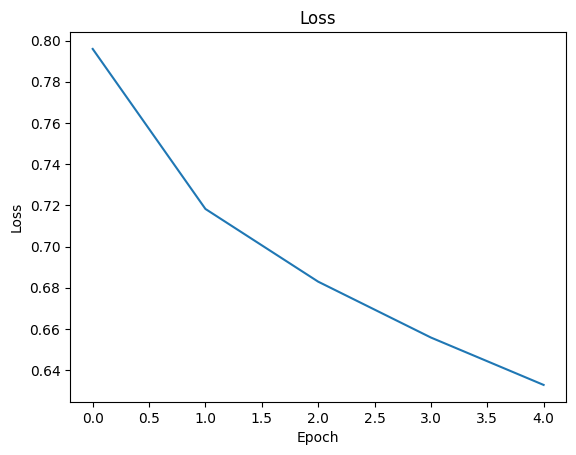

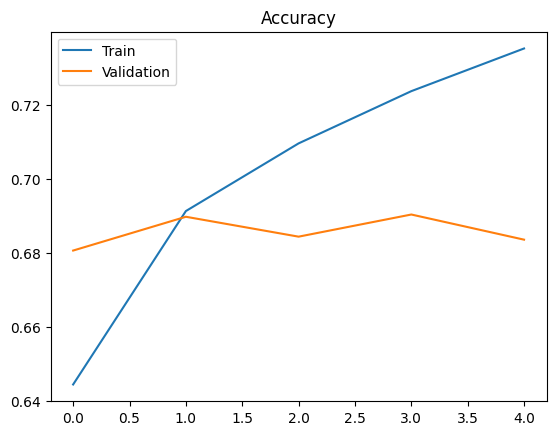

In [39]:
embedding_dim = 50
hidden_size = 20
num_classes = 3

model = biLSTM_Classifier(embedding_dim, hidden_size, num_classes).to(device)
train(model, dataset_train, dataset_val, device, num_epochs=5, learn_rate=0.01)

<h5>Zwiększenie hidden_size</h5>

Epoch 1, Loss: 0.7917, Train Acc: 0.6473, Val Acc: 0.6929
Epoch 2, Loss: 0.7110, Train Acc: 0.6947, Val Acc: 0.6896
Epoch 3, Loss: 0.6727, Train Acc: 0.7145, Val Acc: 0.6948
Epoch 4, Loss: 0.6413, Train Acc: 0.7301, Val Acc: 0.6963
Epoch 5, Loss: 0.6161, Train Acc: 0.7424, Val Acc: 0.6912


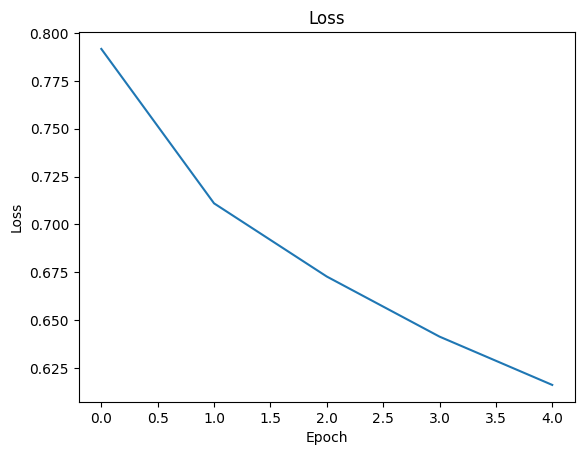

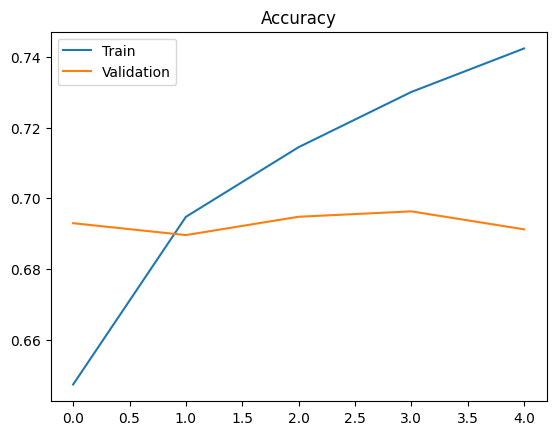

In [40]:
embedding_dim = 50
hidden_size = 128
num_classes = 3

model = biLSTM_Classifier(embedding_dim, hidden_size, num_classes).to(device)
train(model, dataset_train, dataset_val, device, num_epochs=5, learn_rate=0.01)

In [41]:
#Budowa bardziej rozbudowanego modelu biLSTM
class biLSTM_Classifier_v2(nn.Module):
    def __init__(self, embedding_dim, hidden_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(glove.vectors, freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True, bidirectional=True)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size*2*2, hidden_size),
            nn.BatchNorm1d(hidden_size),      #dodanie batchnormalizacji
            nn.ReLU(),                 #dodanie funkcji aktywacji ReLU
            nn.Dropout(0.1),               #dodanie dropout
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, premise_pack, hypothesis_pack):
        pr_data, pr_lens = premise_pack
        hy_data, hy_lens = hypothesis_pack

        #przetwarzanie przesłanki
        embedded_pr = self.embedding(pr_data)
        packed_pr = pack_padded_sequence(embedded_pr, pr_lens.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn_pr, _) = self.lstm(packed_pr)
        pr_vec = torch.cat((hn_pr[-2,:,:], hn_pr[-1,:,:]), dim=1)

        #przetwarzanie hipotezy
        embedded_hy = self.embedding(hy_data)
        packed_hy = pack_padded_sequence(embedded_hy, hy_lens.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn_hy, _) = self.lstm(packed_hy)
        hy_vec = torch.cat((hn_hy[-2,:,:], hn_hy[-1,:,:]), dim=1)

        combined = torch.cat((pr_vec, hy_vec), dim=1)#Konkatenacja wektorów

        return self.classifier(combined)

Epoch 1, Loss: 0.7058, Train Acc: 0.6963, Val Acc: 0.7636
Epoch 2, Loss: 0.5596, Train Acc: 0.7745, Val Acc: 0.7836
Epoch 3, Loss: 0.4980, Train Acc: 0.8026, Val Acc: 0.7903
Epoch 4, Loss: 0.4568, Train Acc: 0.8211, Val Acc: 0.7895
Epoch 5, Loss: 0.4251, Train Acc: 0.8351, Val Acc: 0.7983


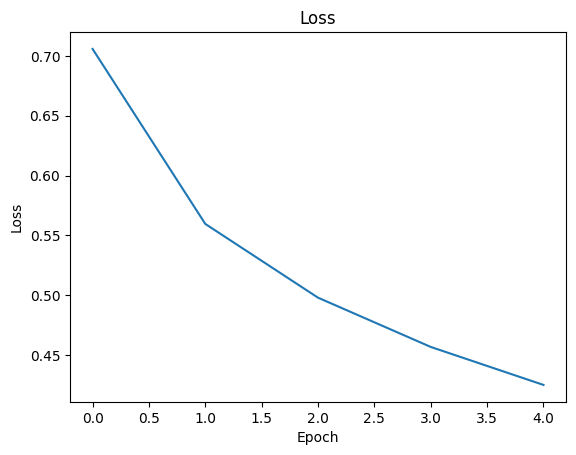

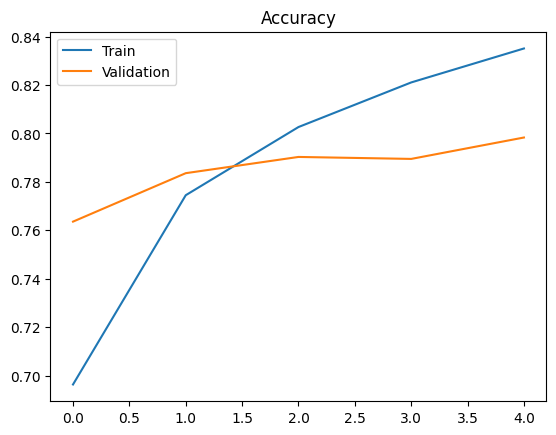

In [42]:
embedding_dim = 50
hidden_size = 128
num_classes = 3

model = biLSTM_Classifier_v2(embedding_dim, hidden_size, num_classes).to(device)
train(model, dataset_train, dataset_val, device, num_epochs=5, learn_rate=0.01)

Epoch 1, Loss: 0.7571, Train Acc: 0.6669, Val Acc: 0.7256
Epoch 2, Loss: 0.6266, Train Acc: 0.7406, Val Acc: 0.7591
Epoch 3, Loss: 0.5768, Train Acc: 0.7657, Val Acc: 0.7719
Epoch 4, Loss: 0.5401, Train Acc: 0.7830, Val Acc: 0.7796
Epoch 5, Loss: 0.5102, Train Acc: 0.7971, Val Acc: 0.7805


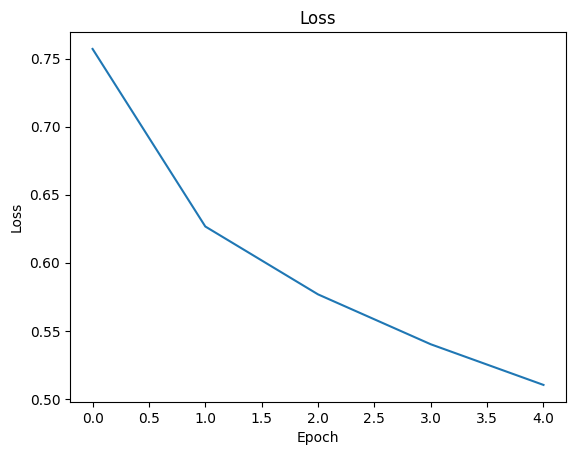

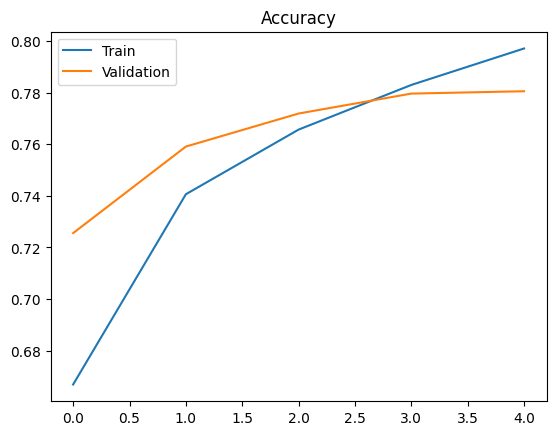

In [43]:
#ponowne użycie modelu biLSTM_classifier ale z mniejszym learning rate
embedding_dim = 50
hidden_size = 128
num_classes = 3

model = biLSTM_Classifier_v2(embedding_dim, hidden_size, num_classes).to(device)
train(model, dataset_train, dataset_val, device, num_epochs=5, learn_rate=0.001)

In [44]:
#Modyfikacja rozbudowanego modelu biLSTM
class biLSTM_Classifier_v3(nn.Module):
    def __init__(self, embedding_dim, hidden_size, num_classes):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(glove.vectors, freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True, bidirectional=True)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size*2*2, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.LeakyReLU(),                 #zamiana na LeakyReLU
            nn.Dropout(0.3),               #zwiększenie dropout
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, premise_pack, hypothesis_pack):
        pr_data, pr_lens = premise_pack
        hy_data, hy_lens = hypothesis_pack

        #przetwarzanie przesłanki
        embedded_pr = self.embedding(pr_data)
        packed_pr = pack_padded_sequence(embedded_pr, pr_lens.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn_pr, _) = self.lstm(packed_pr)
        pr_vec = torch.cat((hn_pr[-2,:,:], hn_pr[-1,:,:]), dim=1)

        #przetwarzanie hipotezy
        embedded_hy = self.embedding(hy_data)
        packed_hy = pack_padded_sequence(embedded_hy, hy_lens.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn_hy, _) = self.lstm(packed_hy)
        hy_vec = torch.cat((hn_hy[-2,:,:], hn_hy[-1,:,:]), dim=1)

        combined = torch.cat((pr_vec, hy_vec), dim=1)#Konkatenacja wektorów

        return self.classifier(combined)

Epoch 1, Loss: 0.7812, Train Acc: 0.6529, Val Acc: 0.7138
Epoch 2, Loss: 0.6508, Train Acc: 0.7290, Val Acc: 0.7537
Epoch 3, Loss: 0.6039, Train Acc: 0.7532, Val Acc: 0.7660
Epoch 4, Loss: 0.5698, Train Acc: 0.7691, Val Acc: 0.7745
Epoch 5, Loss: 0.5427, Train Acc: 0.7819, Val Acc: 0.7785


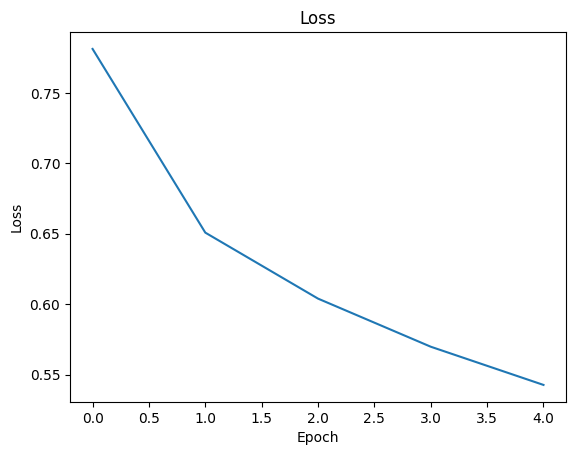

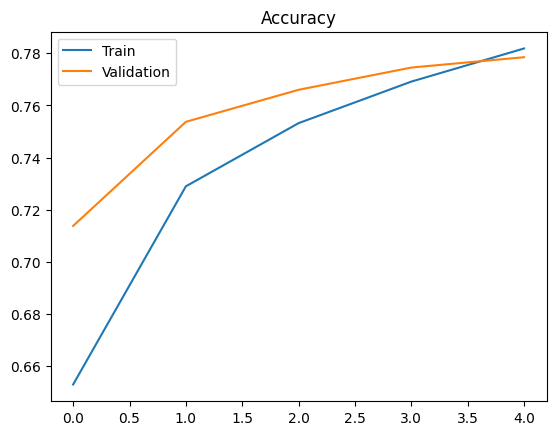

In [46]:
#model biLSTM v3
embedding_dim = 50
hidden_size = 128
num_classes = 3

model = biLSTM_Classifier_v3(embedding_dim, hidden_size, num_classes).to(device)
train(model, dataset_train, dataset_val, device, num_epochs=5, learn_rate=0.001)

<h5>Trenowanie modelu v2 i v3 na 10 epokach a następnie sprawdzenie ich dokładności na zbiorze testowym

Epoch 1, Loss: 0.7615, Train Acc: 0.6637, Val Acc: 0.7278
Epoch 2, Loss: 0.6278, Train Acc: 0.7396, Val Acc: 0.7623
Epoch 3, Loss: 0.5758, Train Acc: 0.7656, Val Acc: 0.7736
Epoch 4, Loss: 0.5388, Train Acc: 0.7836, Val Acc: 0.7734
Epoch 5, Loss: 0.5082, Train Acc: 0.7980, Val Acc: 0.7870
Epoch 6, Loss: 0.4831, Train Acc: 0.8098, Val Acc: 0.7921
Epoch 7, Loss: 0.4599, Train Acc: 0.8203, Val Acc: 0.7941
Epoch 8, Loss: 0.4406, Train Acc: 0.8284, Val Acc: 0.7978
Epoch 9, Loss: 0.4226, Train Acc: 0.8361, Val Acc: 0.7976
Epoch 10, Loss: 0.4046, Train Acc: 0.8436, Val Acc: 0.8018


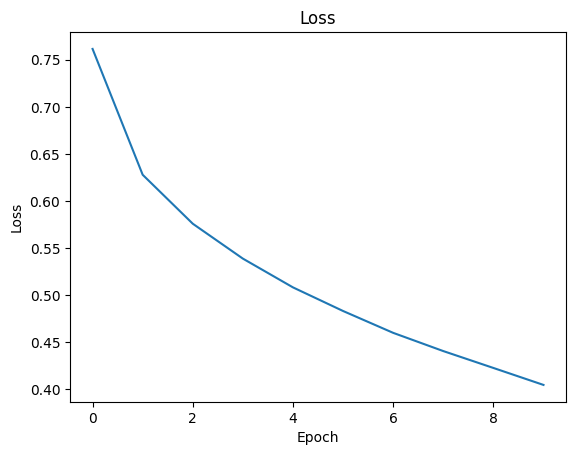

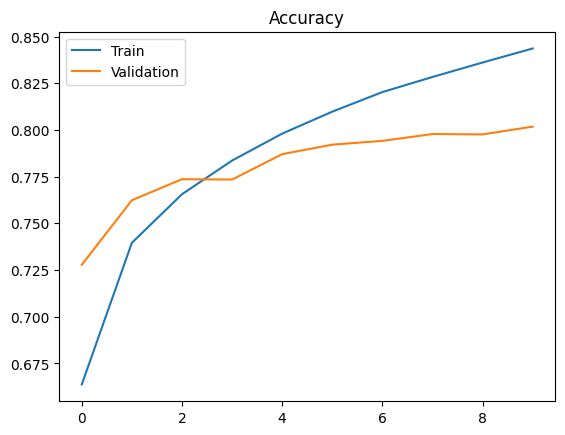

In [48]:
#Trenowanie modelu v2
embedding_dim = 50
hidden_size = 128
num_classes = 3

model = biLSTM_Classifier_v2(embedding_dim, hidden_size, num_classes).to(device)
train(model, dataset_train, dataset_val, device, num_epochs=10, learn_rate=0.001)

In [49]:
#Testowanie modelu v2
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for pr_pack, hy_pack, labels in loader_test:
        pr_idx, pr_len = pr_pack
        hy_idx, hy_len = hy_pack
        pr_pack = (pr_idx.to(device), pr_len)
        hy_pack = (hy_idx.to(device), hy_len)
        labels = labels.to(device)

        outputs = model(pr_pack, hy_pack)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

#Classification report
idx_to_label = {0: "entailment", 1: "contradiction", 2: "neutral"}
print(classification_report(all_labels, all_preds, target_names=list(idx_to_label.values())))

               precision    recall  f1-score   support

   entailment       0.79      0.86      0.82      3368
contradiction       0.83      0.80      0.82      3237
      neutral       0.78      0.73      0.75      3219

     accuracy                           0.80      9824
    macro avg       0.80      0.80      0.80      9824
 weighted avg       0.80      0.80      0.80      9824



Epoch 1, Loss: 0.7842, Train Acc: 0.6500, Val Acc: 0.7281
Epoch 2, Loss: 0.6508, Train Acc: 0.7292, Val Acc: 0.7447
Epoch 3, Loss: 0.6022, Train Acc: 0.7542, Val Acc: 0.7648
Epoch 4, Loss: 0.5689, Train Acc: 0.7701, Val Acc: 0.7712
Epoch 5, Loss: 0.5415, Train Acc: 0.7827, Val Acc: 0.7855
Epoch 6, Loss: 0.5196, Train Acc: 0.7928, Val Acc: 0.7899
Epoch 7, Loss: 0.5011, Train Acc: 0.8019, Val Acc: 0.7910
Epoch 8, Loss: 0.4835, Train Acc: 0.8095, Val Acc: 0.7957
Epoch 9, Loss: 0.4678, Train Acc: 0.8164, Val Acc: 0.7968
Epoch 10, Loss: 0.4544, Train Acc: 0.8223, Val Acc: 0.7958


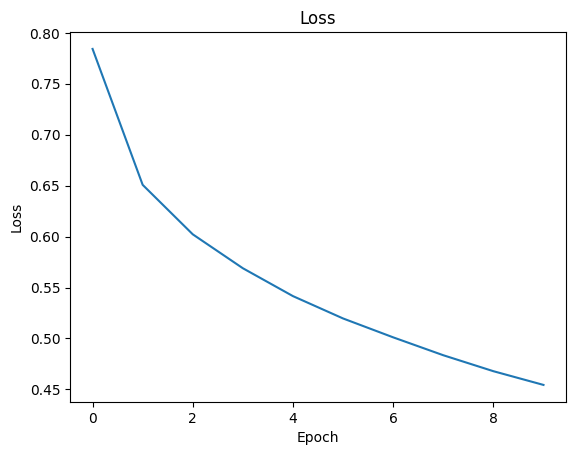

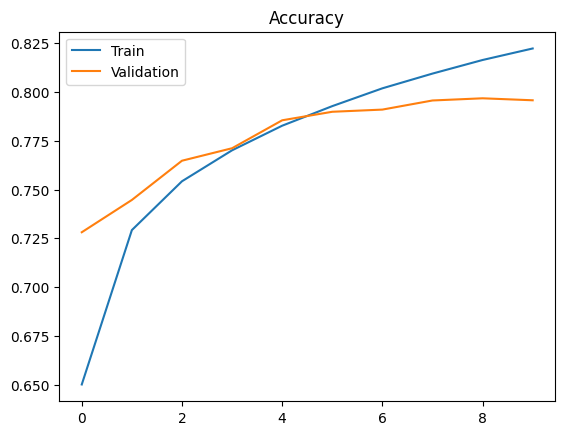

In [50]:
#Trenowanie modelu v3
embedding_dim = 50
hidden_size = 128
num_classes = 3

model = biLSTM_Classifier_v3(embedding_dim, hidden_size, num_classes).to(device)
train(model, dataset_train, dataset_val, device, num_epochs=10, learn_rate=0.001)

In [51]:
#Testowanie modelu v3
from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for pr_pack, hy_pack, labels in loader_test:
        pr_idx, pr_len = pr_pack
        hy_idx, hy_len = hy_pack
        pr_pack = (pr_idx.to(device), pr_len)
        hy_pack = (hy_idx.to(device), hy_len)
        labels = labels.to(device)

        outputs = model(pr_pack, hy_pack)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

#Classification report
idx_to_label = {0: "entailment", 1: "contradiction", 2: "neutral"}
print(classification_report(all_labels, all_preds, target_names=list(idx_to_label.values())))

               precision    recall  f1-score   support

   entailment       0.78      0.85      0.81      3368
contradiction       0.82      0.78      0.80      3237
      neutral       0.76      0.74      0.75      3219

     accuracy                           0.79      9824
    macro avg       0.79      0.79      0.79      9824
 weighted avg       0.79      0.79      0.79      9824



Epoch 1, Loss: 0.7645, Train Acc: 0.6615, Val Acc: 0.7255
Epoch 2, Loss: 0.6242, Train Acc: 0.7421, Val Acc: 0.7578
Epoch 3, Loss: 0.5738, Train Acc: 0.7676, Val Acc: 0.7700
Epoch 4, Loss: 0.5375, Train Acc: 0.7842, Val Acc: 0.7818
Epoch 5, Loss: 0.5074, Train Acc: 0.7981, Val Acc: 0.7909
Epoch 6, Loss: 0.4818, Train Acc: 0.8102, Val Acc: 0.7884
Epoch 7, Loss: 0.4601, Train Acc: 0.8197, Val Acc: 0.7910
Epoch 8, Loss: 0.4407, Train Acc: 0.8278, Val Acc: 0.7964
Epoch 9, Loss: 0.4228, Train Acc: 0.8361, Val Acc: 0.8025
Epoch 10, Loss: 0.4059, Train Acc: 0.8436, Val Acc: 0.8017


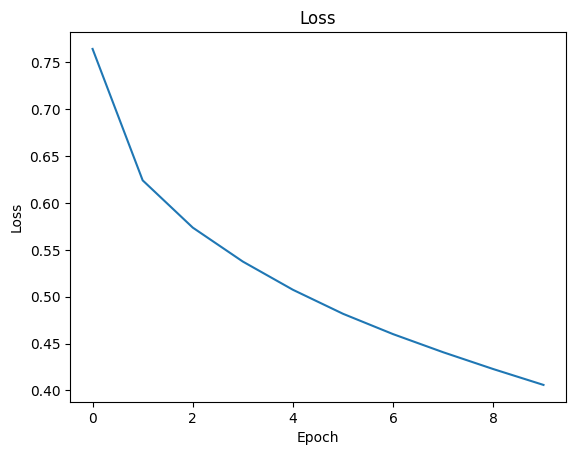

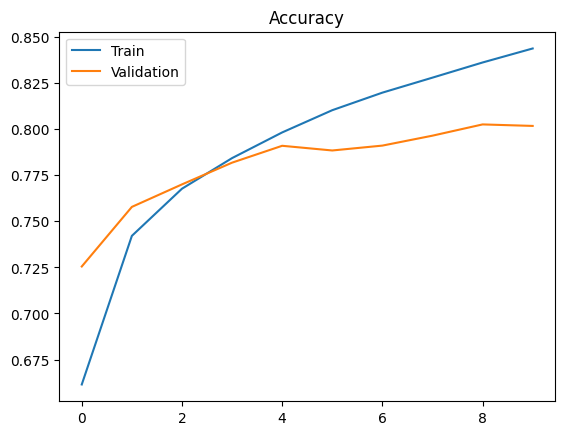

In [67]:
#Ponowne wykorzystanie modelu v2 ponieważ ma lepsze wyniki w classification_report
embedding_dim = 50
hidden_size = 128
num_classes = 3

model = biLSTM_Classifier_v2(embedding_dim, hidden_size, num_classes).to(device)
train(model, dataset_train, dataset_val, device, num_epochs=10, learn_rate=0.001)

In [68]:
#Testowanie modelu v2 na własnych przykładach
def predict(model, premise, hypothesis, device):
    model.eval()
    idx_to_label = {0: "entailment", 1: "contradiction", 2: "neutral"}

    pr_tensor = torch.tensor(text_to_indices(premise), dtype=torch.long).unsqueeze(0).to(device)
    hy_tensor = torch.tensor(text_to_indices(hypothesis), dtype=torch.long).unsqueeze(0).to(device)
    pr_len = torch.tensor([pr_tensor.size(1)])
    hy_len = torch.tensor([hy_tensor.size(1)])

    with torch.no_grad():
        output = model((pr_tensor, pr_len), (hy_tensor, hy_len))
        pred = output.argmax(dim=1).item()
        print("---------------------------------")

    print(f"Przesłanka:{premise}")
    print(f"Hipoteza:{hypothesis}")
    print(f"Predykcja:{idx_to_label[pred]}")

In [69]:
predict(model, "I do not like jazz.", "When I was younger I used to sleep longer.", device)
predict(model, "You look hungry.", "You should eat something.", device)
predict(model, "Gardening is what makes me happy.", "All those trees and flowers, I hate them.", device)

---------------------------------
Przesłanka:I do not like jazz.
Hipoteza:When I was younger I used to sleep longer.
Predykcja:contradiction
---------------------------------
Przesłanka:You look hungry.
Hipoteza:You should eat something.
Predykcja:entailment
---------------------------------
Przesłanka:Gardening is what makes me happy.
Hipoteza:All those trees and flowers, I hate them.
Predykcja:contradiction
